5. **How do you compare two implementations of the same function and detect where they disagree?**
   Example: one version uses NumPy directly, the other uses `lambdify`.
   You need a max error check, but also a way to inspect the bad points.

313.0 : 313.0
288.5 : 288.5
265.0 : 265.0
242.5 : 242.5
221.0 : 221.0
200.5 : 200.5
181.0 : 181.0
162.5 : 162.5
145.0 : 145.0
128.5 : 128.5
113.0 : 113.0
98.5 : 98.5
85.0 : 85.0
72.5 : 72.5
61.0 : 61.0
50.5 : 50.5
41.0 : 41.0
32.5 : 32.5
25.0 : 25.0
18.5 : 18.5
13.0 : 13.0
8.5 : 8.5
5.0 : 5.0
2.5 : 2.5
1.0 : 1.0
0.5 : 0.5
1.0 : 1.0
2.5 : 2.5
5.0 : 5.0
8.5 : 8.5
13.0 : 13.0
18.5 : 18.5
25.0 : 25.0
32.5 : 32.5
41.0 : 41.0
50.5 : 50.5
61.0 : 61.0
72.5 : 72.5
85.0 : 85.0
98.5 : 98.5
113.0 : 113.0
128.5 : 128.5
145.0 : 145.0
162.5 : 162.5
181.0 : 181.0
200.5 : 200.5
221.0 : 221.0
242.5 : 242.5
265.0 : 265.0
288.5 : 288.5


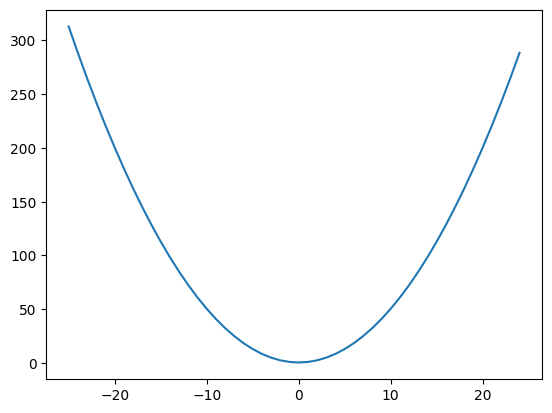

In [1]:
"""5. **How do you compare two implementations of the same function and detect where they disagree?**
   Example: one version uses NumPy directly, the other uses `lambdify`.
   You need a max error check, but also a way to inspect the bad points."""

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp


x_numpy = np.arange(-25,25)
y_numpy = np.copy(x_numpy)

y_numpy1 = (np.square(y_numpy) + 1)/2

x_sym = sp.symbols("x")
expr = (((x_sym**2) + 1)/2)
f_sym = sp.lambdify(x_sym, expr, "numpy")
y_sympy = f_sym(x_numpy)

for numpy, sympy in zip(y_numpy1, y_sympy):
    print(f"{numpy} : {sympy}")

plt.plot(x_numpy,y_numpy1)



Max error: 0.0

Bad points:



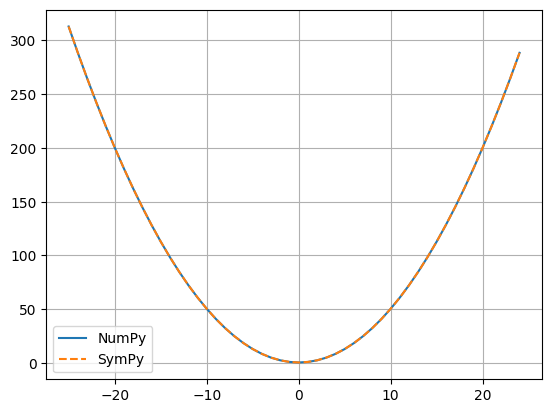

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

x_numpy = np.arange(-25,25)

# NumPy implementation
y_numpy = (x_numpy**2 + 1) / 2

# SymPy implementation
x_sym = sp.symbols("x")
expr = (x_sym**2 + 1) / 2

f_sym = sp.lambdify(x_sym, expr, "numpy")
y_sympy = f_sym(x_numpy)

# Absolute error
error = np.abs(y_numpy - y_sympy)

# Find disagreement points
bad_mask = error > 1e-10

print("\nBad points:\n")

for x_val, y1, y2, err in zip(
    x_numpy[bad_mask],
    y_numpy[bad_mask],
    y_sympy[bad_mask],
    error[bad_mask]
):
    print(f"x={x_val}, numpy={y1}, sympy={y2}, error={err}")

plt.plot(x_numpy, y_numpy, label="NumPy")
plt.plot(x_numpy, y_sympy, linestyle="--", label="SymPy")

plt.legend()
plt.grid()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extremely tiny region near zero
x = np.linspace(-1e-8, 1e-8, 5000)

# Avoid division by zero
mask = x != 0

# -----------------------------------
# Implementation 1
# -----------------------------------

y1 = np.full_like(x, np.nan)

y1[mask] = (
    1 - np.cos(x[mask])
) / (x[mask]**2)

# -----------------------------------
# Implementation 2
# -----------------------------------

y2 = np.full_like(x, np.nan)

y2[mask] = (
    2 * np.sin(x[mask]/2)**2
) / (x[mask]**2)

# -----------------------------------
# Error analysis
# -----------------------------------

error = np.abs(y1 - y2)

print("Maximum error:", np.nanmax(error))

# -----------------------------------
# Bad points
# -----------------------------------

tolerance = 1e-16

bad_mask = error > tolerance

print("\nDisagreement points:\n")

for xv, a, b, err in zip(
    x[bad_mask],
    y1[bad_mask],
    y2[bad_mask],
    error[bad_mask]
):
    print(
        f"x={xv:.2e} | "
        f"impl1={a:.18f} | "
        f"impl2={b:.18f} | "
        f"error={err:.3e}"
    )

# -----------------------------------
# Plot error
# -----------------------------------

plt.plot(x, error)

plt.title("Numerical Error Between Equivalent Forms")

plt.xlabel("x")
plt.ylabel("Absolute Error")

plt.grid(True)

plt.show()

-----

In [5]:
import numpy as np

# Input values
x = np.arange(0,5)

# Implementation 1
y1 = (np.sqrt(x))**2

# Implementation 2
y2 = x

# Compare
error = np.abs(y1 - y2)

print("\nComparison:\n")

for xv, a, b, err in zip(x, y1, y2, error):
    print(
        f"x = {xv}"
        f" | impl1 = {a}"
        f" | impl2 = {b}"
        f" | error = {err}"
    )
print("\nMaximum error:", np.max(error))


Comparison:

x = 0 | impl1 = 0.0 | impl2 = 0 | error = 0.0
x = 1 | impl1 = 1.0 | impl2 = 1 | error = 0.0
x = 2 | impl1 = 2.0000000000000004 | impl2 = 2 | error = 4.440892098500626e-16
x = 3 | impl1 = 2.9999999999999996 | impl2 = 3 | error = 4.440892098500626e-16
x = 4 | impl1 = 4.0 | impl2 = 4 | error = 0.0

Maximum error: 4.440892098500626e-16


----

In [ ]:
import numpy as np

x_numpy = np.array([10, 20, 30, 40, 50])
y_numpy = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_sympy = np.array([1.0, 2.2, 3.0, 4.5, 5.0])

error = np.abs(y_numpy - y_sympy)
tolerance = 0.1
bad_mask = error > tolerance

print("error    =", error)
print("bad_mask =", bad_mask)
print()

for x_val, y1, y2, err in zip(
    x_numpy[bad_mask],
    y_numpy[bad_mask],
    y_sympy[bad_mask],
    error[bad_mask]
):
    print(f"x={x_val}, numpy={y1}, sympy={y2}, error={err}")

error    = [0.  0.2 0.  0.5 0. ]
bad_mask = [False  True False  True False]

x=20, numpy=2.0, sympy=2.2, error=0.20000000000000018
x=40, numpy=4.0, sympy=4.5, error=0.5


In [3]:
import numpy as np

names = np.array(["A", "B", "C", "D"])
ages = np.array([18, 25, 17, 30])
salary = np.array([100, 200, 150, 300])

mask = ages >= 18

print(names[mask])
print(ages[mask])
print(salary[mask])

['A' 'B' 'D']
[18 25 30]
[100 200 300]
